In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import time

print("Libraries loaded!")

Libraries loaded!


In [2]:
#Load bookings and filter to Goa + Manali 2024
df = pd.read_csv('../hotel_bookings (1).csv', keep_default_na=False)
df['checkin_date']  = pd.to_datetime(df['checkin_date'])
df['checkout_date'] = pd.to_datetime(df['checkout_date'])
sample = df[
    (df['property_city'].isin(['Goa', 'Manali'])) &
    (df['checkin_date'].dt.year == 2024) &
    (df['checkout_date'] > df['checkin_date']) &  # Footnote 1
    (df['num_rooms'] > 0)                          # Footnote 3
].copy()

print(f"Total bookings in sample: {len(sample)}")
print(f"Goa    : {(sample['property_city']=='Goa').sum()}")
print(f"Manali : {(sample['property_city']=='Manali').sum()}")
print(f"Date range: {sample['checkin_date'].min()} to {sample['checkin_date'].max()}")

Total bookings in sample: 1582
Goa    : 876
Manali : 706
Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00


In [3]:
#  Fetch weather data from  API

# City coordinates
CITY_COORDS = {
    'Goa'   : {'latitude': 15.4909, 'longitude': 73.8278},
    'Manali': {'latitude': 32.2432, 'longitude': 77.1892}
}

def fetch_weather(city, start_date, end_date):
    """
    Fetch daily weather for a city between two dates.
    Returns a DataFrame with date, precipitation, max temperature.
    Returns empty DataFrame on any error — never crashes the program.
    """
    coords = CITY_COORDS[city]
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        'latitude'   : coords['latitude'],
        'longitude'  : coords['longitude'],
        'start_date' : start_date,
        'end_date'   : end_date,
        'daily'      : 'precipitation_sum,temperature_2m_max',
        'timezone'   : 'Asia/Kolkata'
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        weather_df = pd.DataFrame({
            'date'          : pd.to_datetime(data['daily']['time']),
            'precipitation' : data['daily']['precipitation_sum'],
            'temp_max'      : data['daily']['temperature_2m_max'],
            'city'          : city
        })

        return weather_df
    except requests.exceptions.Timeout:
        print(f"Timeout fetching {city} — skipping")
        return pd.DataFrame()

    except requests.exceptions.RequestException as e:
        print(f"Error fetching {city}: {e} — skipping")
        return pd.DataFrame()

    except KeyError:
        print(f"Unexpected response format for {city} — skipping")
        return pd.DataFrame()


# WEATHER FOR BOTH CITIES
all_weather = []
for city in ['Goa', 'Manali']:
    city_bookings = sample[sample['property_city'] == city]
    if len(city_bookings) == 0:
        print(f"No bookings for {city} — skipping")
        continue
    start = city_bookings['checkin_date'].min().strftime('%Y-%m-%d')
    end   = city_bookings['checkin_date'].max().strftime('%Y-%m-%d')
    print(f"Fetching weather for {city}: {start} to {end}...")
    weather = fetch_weather(city, start, end)
    if len(weather) > 0:
        all_weather.append(weather)
        print(f"  Got {len(weather)} days of weather data")
    else:
        print(f"  No data returned for {city}")
    time.sleep(1)
if all_weather:
    weather_df = pd.concat(all_weather, ignore_index=True)
    print(f"\nTotal weather records: {len(weather_df)}")
    print(weather_df.head())
else:
    print("No weather data fetched — check internet connection")

Fetching weather for Goa: 2024-01-01 to 2024-12-31...
  Got 366 days of weather data
Fetching weather for Manali: 2024-01-02 to 2024-12-31...
  Got 365 days of weather data

Total weather records: 731
        date  precipitation  temp_max city
0 2024-01-01            0.0      32.2  Goa
1 2024-01-02            0.0      32.6  Goa
2 2024-01-03            0.0      33.4  Goa
3 2024-01-04            0.7      31.3  Goa
4 2024-01-05            0.0      30.8  Goa


In [4]:
# Merge weather data onto bookings
# Rename weather columns to match booking columns for merging
weather_merge = weather_df.rename(columns={
    'date' : 'checkin_date',
    'city' : 'property_city'
})
# Merge — left join keeps all bookings even if no weather data found
merged = sample.merge(
    weather_merge,
    on=['checkin_date', 'property_city'],
    how='left'
)
print(f"Bookings before merge : {len(sample)}")
print(f"Bookings after merge  : {len(merged)}")
print(f"Missing weather data  : {merged['precipitation'].isna().sum()}")
print()
print("Sample of merged data:")
print(merged[['property_city', 'checkin_date', 'booking_status',
              'precipitation', 'temp_max']].head(8))

Bookings before merge : 1582
Bookings after merge  : 1582
Missing weather data  : 0

Sample of merged data:
  property_city checkin_date booking_status  precipitation  temp_max
0        Manali   2024-08-30      Cancelled            1.6      24.7
1           Goa   2024-01-18      Completed            0.0      30.5
2        Manali   2024-12-18      Cancelled            0.0      15.1
3        Manali   2024-11-17        No-Show            2.5      13.7
4        Manali   2024-07-16      Completed            0.3      26.3
5           Goa   2024-04-05      Completed            0.0      32.3
6        Manali   2024-08-28      Completed            0.0      24.2
7        Manali   2024-02-24      Completed            7.3       4.6


In [5]:
# Cell 5: Classify weather conditions
merged['heavy_rain'] = merged['precipitation'] > 10
merged['extreme_heat'] = merged['temp_max'] > 35
merged['extreme_cold'] = merged['temp_max'] < 5

merged['weather_condition'] = 'Normal'
merged.loc[merged['heavy_rain'],    'weather_condition'] = 'Heavy Rain'
merged.loc[merged['extreme_heat'],  'weather_condition'] = 'Extreme Heat'
merged.loc[merged['extreme_cold'],  'weather_condition'] = 'Extreme Cold'

print("Weather condition distribution:")
print(merged.groupby(['property_city', 'weather_condition']).size())

Weather condition distribution:
property_city  weather_condition
Goa            Extreme Heat           8
               Heavy Rain           211
               Normal               657
Manali         Extreme Cold           3
               Heavy Rain           181
               Normal               522
dtype: int64


In [6]:
# Cell 6: The non-obvious insight
# Does bad weather correlate with higher cancellation rates?
print("=" * 55)
print("WEATHER vs CANCELLATION RATE ANALYSIS")
print("=" * 55)

# Drop rows with missing weather data for clean analysis
analysis = merged.dropna(subset=['precipitation', 'temp_max'])

# Cancellation rate by city + weather condition
result = analysis.groupby(
    ['property_city', 'weather_condition']
)['booking_status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100
).round(1).reset_index()

result.columns = ['City', 'Weather', 'Cancel Rate (%)']
result = result.sort_values(['City', 'Cancel Rate (%)'], ascending=[True, False])

print(result.to_string(index=False))

print()
print("=" * 55)
print("BOOKING COUNTS BY CONDITION")
print("=" * 55)

counts = analysis.groupby(
    ['property_city', 'weather_condition']
).size().reset_index()
counts.columns = ['City', 'Weather', 'Bookings']
print(counts.to_string(index=False))

WEATHER vs CANCELLATION RATE ANALYSIS
  City      Weather  Cancel Rate (%)
   Goa   Heavy Rain             36.5
   Goa       Normal             23.0
   Goa Extreme Heat              0.0
Manali   Heavy Rain             22.1
Manali       Normal             21.1
Manali Extreme Cold              0.0

BOOKING COUNTS BY CONDITION
  City      Weather  Bookings
   Goa Extreme Heat         8
   Goa   Heavy Rain       211
   Goa       Normal       657
Manali Extreme Cold         3
Manali   Heavy Rain       181
Manali       Normal       522


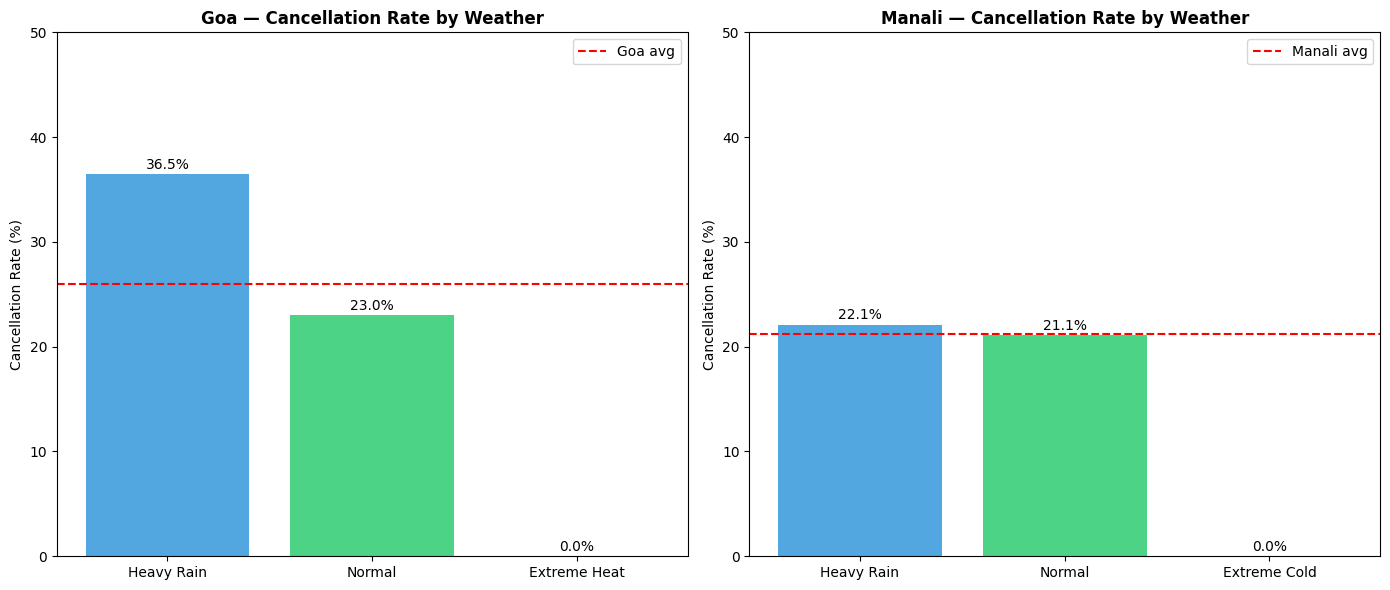

Chart saved!


In [7]:
# Cell 7: Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cities = ['Goa', 'Manali']
colors = {
    'Normal'      : '#2ecc71',
    'Heavy Rain'  : '#3498db',
    'Extreme Heat': '#e74c3c',
    'Extreme Cold': '#9b59b6'
}

for i, city in enumerate(cities):
    city_data = result[result['City'] == city]
    bars = axes[i].bar(
        city_data['Weather'],
        city_data['Cancel Rate (%)'],
        color=[colors.get(w, '#95a5a6') for w in city_data['Weather']],
        alpha=0.85
    )
    axes[i].axhline(
        y=analysis[analysis['property_city']==city]['booking_status']
        .apply(lambda x: 1 if x=='Cancelled' else 0).mean()*100,
        color='red', linestyle='--', linewidth=1.5,
        label=f'{city} avg'
    )
    axes[i].set_title(f'{city} — Cancellation Rate by Weather', fontweight='bold')
    axes[i].set_ylabel('Cancellation Rate (%)')
    axes[i].set_ylim(0, 50)
    axes[i].legend()

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f'{height:.1f}%',
            ha='center', fontsize=10
        )

plt.tight_layout()
plt.savefig('weather_cancellation.png', dpi=150)
plt.show()
print("Chart saved!")